#  Ajustement de cercle et d'ellipse par moindres carrés 

### Nour Bouabid et Marya Khelifa

> **Objectif :** Étant donné un nuage de points (potentiellement bruités), retrouver le centre $(x_c, y_c)$ et le rayon $r$ du cercle qui les ajuste au mieux.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
from scipy.optimize import least_squares
import time

---
# Méthode 1 - Moindres carrés linéaires
## 1.  Principe Mathématique — Linéarisation

L'équation générale d'un cercle de centre $(x_c, y_c)$ et de rayon $r$ est :

$$
(x - x_c)^2 + (y - y_c)^2 = r^2
$$

**Développement :**

$$
x^2 - 2x x_c + x_c^2 + y^2 - 2y y_c + y_c^2 = r^2
$$

On regroupe les termes connus $(x^2 + y^2)$ à droite :

$$
2x \cdot x_c + 2y \cdot y_c + (r^2 - x_c^2 - y_c^2) = x^2 + y^2
$$

###  Substitution — Passage au système linéaire

On introduit trois nouvelles inconnues pour **linéariser** le problème :

| Inconnue | Définition | Récupération finale |
|:--------:|:----------:|:-------------------:|
| $a$ | $-2x_c$ | $x_c = -a/2$ |
| $b$ | $-2y_c$ | $y_c = -b/2$ |
| $c$ | $x_c^2 + y_c^2 - r^2$ | $r = \sqrt{x_c^2 + y_c^2 - c}$ |

Le système devient **linéaire** en $(a, b, c)$ :

$$
\boxed{a \cdot x + b \cdot y + c = -(x^2 + y^2)}
$$

---
## 2.  Formulation Matricielle

Pour $n$ points $(x_i, y_i)$, on écrit le système $A\,\theta = \mathbf{B}$ :

$$
\underbrace{\begin{bmatrix} x_1 & y_1 & 1 \\ x_2 & y_2 & 1 \\ \vdots & \vdots & \vdots \\ x_n & y_n & 1 \end{bmatrix}}_{A \in \mathbb{R}^{n \times 3}}
\underbrace{\begin{bmatrix} a \\ b \\ c \end{bmatrix}}_{\theta}
=
\underbrace{\begin{bmatrix} -(x_1^2 + y_1^2) \\ -(x_2^2 + y_2^2) \\ \vdots \\ -(x_n^2 + y_n^2) \end{bmatrix}}_{\mathbf{B}}
$$

Comme le système est **sur-déterminé** ($n \gg 3$) (ie: l'ensemble des solutions peut etre vide), on le résout au sens des **moindres carrés** :

$$
\theta^* = \arg\min_\theta \|A\theta - \mathbf{B}\|^2
$$

Ce qui correspond à la solution de l'équation normale : $A^T A\, \theta = A^T \mathbf{B}$.

---
## 3.  Implémentation

In [2]:
def methode1(x, y):
    """
    Ajuste un cercle à un nuage de points par moindres carrés linéaires.

    Paramètres
    ----------
    x, y : array — coordonnées des points

    Retourne
    --------
    xc, yc : float — centre estimé
    r      : float — rayon estimé
    """

    # Matrice A : chaque ligne = [xi, yi, 1] pour le point i
    A = np.column_stack((x, y, np.ones(len(x))))

    # Vecteur b : membre droit après passage de x²+y² à gauche
    b = -(x**2 + y**2)

    # Résolution par moindres carrés
    a_coef, b_coef, c_coef = np.linalg.lstsq(A, b, rcond=None)[0]

    # Récupération du centre
    xc = -a_coef / 2
    yc = -b_coef / 2

    # Récupération du rayon
    r = np.sqrt(xc**2 + yc**2 - c_coef)

    return xc, yc, r

# Méthode 2 — Ajustement par moindres carrés géométriques

On note
$
\theta=(x_c,y_c,r)\in\mathbb{R}^2\times\mathbb{R}_+.
$

La fonction à minimiser est :
$
F(\theta) =\sum_{i=1}^n\left(\sqrt{(x_i-x_c)^2+(y_i-y_c)^2}-r\right)^2
=\sum_{i=1}^n \rho_i(\theta)^2
$

en notant
$
\rho_i(\theta)=\sqrt{(x_i-x_c)^2+(y_i-y_c)^2}-r
$ , le résidu géométrique.

---
### 1.Existence d’un minimiseur

La fonction $F$ est continue sur $\mathbb{R}^2\times\mathbb{R}_+$.

- à $(x_c,y_c)$ fixé, la fonction $r\mapsto F(x_c,y_c,r)$ est convexe et son gradient s'annule, elle admet donc un minimum.
- à $r$ fixé, $(x_c,y_c)\mapsto F(x_c,y_c,r)$ est infini à l'infini, donc elle admet au moins un minimimum.

F admet donc au moins un minimiseur.

---

### 2. Formulation vectorielle

On introduit le vecteur des résidus

$
\rho(\theta)=
\begin{pmatrix}
\rho_1(\theta)\\
\vdots\\
\rho_n(\theta)
\end{pmatrix}
\in\mathbb{R}^n
$

On a alors $F(\theta)=\|\rho(\theta)\|_2^2$


### 3. Aproximation du minimiseur par la methode de Gausse-Newton

On construit une suite $(\theta_n)_{n\ge0}$ convergent vers un minimiseur $\theta^*$.


Soit $n \in \mathbb{N}$ et $\theta_n$ $\in\mathbb{R}^3$, la fonction $\rho$ étant $\mathcal C^1$, pour tout $h$ on a:

$$\rho(\theta_n+h)=\rho(\theta_n)+J_\rho(\theta_n)h+o(\|h\|)$$

où $J_\rho(\theta_n)\in\mathbb{R}^{n\times3}$ est la jacobienne de $\rho$ en $\theta_n$.

Ainsi $$F(\theta_n+h)\approx\|\rho(\theta_n)+J_\rho(\theta_n)h\|^2$$

D'après la formule de l'estimateur des moindres carrées cité plus haut, Si $J_\rho(\theta_n)^T J_\rho(\theta_n)$ est inversible, cette quantité est minimisée par :

$$h^*= -(J_\rho(\theta_n)^T J_\rho(\theta_n))^{-1}J_\rho(\theta_n)^T\rho(\theta_n)$$

on note alors $h^*:=h_n$ et $\theta_{n+1}=\theta_n+h_n$

Supposons que la suite $(\theta_n)$ converge vers une limite $\theta^*$, comme $\theta_{n+1}-\theta_n=h_n$ par unicité de la limite $h_n\to 0$.

En passant à la limite lorsque $n\to+\infty$, on obtient
$$
0=-(J_\rho(\theta^*)^T J(\theta^*))^{-1}J_\rho(\theta^*)^T\rho(\theta^*).
$$

Comme on a supposé que $J_\rho(\theta^*)^T J_\rho(\theta^*)$ est inversible, il vient
$$
J_\rho(\theta^*)^T\rho(\theta^*)=0.
$$

Ainsi,
$$
\nabla F(\theta^*)=2J_\rho(\theta^*)^T\rho(\theta^*)=0.
$$

et $\theta^*$ est un point critique de $F$.

Enfin, sous des hypothèses supplémentaires sur $F$, ce point critique est un minimiseur local. Par exemple, si $F$ est convexe au voisinage de $\theta^*$ ou si la hessienne de F est semie définie positive en $\theta^*$. 

---

### 4. Méthode de Levenberg–Marquardt

Afin d’améliorer la stabilité numérique, on considère la minimisation régularisée

$\min_h\|\rho(\theta_n)+J_\rho(\theta_n)h\|^2+\lambda_n\|h\|^2,\qquad \lambda_n>0$

En calculant le zéro du gradient on trouve que le minimiseur $h^*$ vérifie cette fois:

$$h^*=-(J_\rho(\theta_n)^T J_\rho(\theta_n)+\lambda_n I)^{-1}J_\rho(\theta_n)^T\rho(\theta_n)$$

Ou $J_\rho(\theta_n)^T J_\rho(\theta_n)+\lambda_n I$ est définie positive pour $\lambda_n>0$, ce qui garantit l’inversibilité du système.

Et on définit de la même façon $\theta_{n+1}=\theta_n+h_n$

La méthode de Levenberg–Marquardt concilie deux methodes :

- La descente de gradient pour $\lambda_n$ grand
- la méthode de Gauss–Newton pour $\lambda_n$ petit

Elle offre ainsi une meilleure robustesse loin du minimum tout en conservant une convergence rapide au voisinage de la solution.

---
### 5. implémentation


In [ ]:
#minimisation sans contrainte
def methode2(x, y, method='lm',max_nfev=1000):
    '''
    (x,y): données
    method: par défaut methode Levenberg-Marquardt avec régularisation
    ----
    minimisation sans contraintes
    précision?
    '''
    #definition de la fonction des residus
    def residus(theta):
        xc, yc, r = theta
        return np.sqrt((x-xc)**2 + (y-yc)**2) - r
    
    # initialisation
    xc0 = np.mean(x)
    yc0 = np.mean(y)
    r0  = np.mean(np.sqrt((x-xc0)**2 + (y-yc0)**2))

    result = least_squares(residus, x0=(xc0, yc0, r0), method=method, max_nfev=max_nfev)  #max nombre d'itération1000
    #voir vitesse de convergence et critère d'arret
    
    return result.x
#LM est une version améliorée de la methode de Gausse-Newton, étudier la convergence de la suite des paramêtres

---
# Méthode 3 — Ajustement par moindres carrés géométriques avec contrainte

On ajoute à la methode 2 la contrainte suivante: le point $(x_n,y_n)$ appartient au cercle. Le rayon est alors entièrement déterminé par ce point et les paramêtres $(x_c,y_c)$.
$$r=\sqrt{(x_n-x_c)^2 + (y_n -y_c)^2}$$

In [4]:
def methode3(x,y, method='lm',max_nfev=1000):
    '''
    minimisation avec contrainte
    Datas (x,y)
    par défaut methode Levenberg-Marquardt avec régularisation
    '''

    #definition des residus avec contrainte
    def residus(theta):
        xc, yc = theta #2 paramêtres car r dépend de xc et yc
        r = np.mean(np.sqrt((x[-1]-xc)**2 + (y[-1]-yc)**2))
        return np.sqrt((x-xc)**2 + (y-yc)**2) - r
    
    # initialisation
    xc0 = np.mean(x)
    yc0 = np.mean(y)

    result = least_squares(residus, x0=(xc0, yc0), method=method, max_nfev=max_nfev)  #max nombre d'itération 1000
    
    xc,yc = result.x
    r=np.sqrt((x[-1]-xc)**2 + (y[-1]-yc)**2)

    return xc,yc,r

---
# Test sur un jeu de données créé

On génère $n = 10$ points sur un cercle de rayon $r = 3$ centré à l'origine, puis on ajoute un bruit gaussien :

$$
\varepsilon \sim \mathcal{N}\bigl(0,\, \sigma\bigr), \quad \sigma = 0.5
$$

In [5]:
#random.seed()

In [24]:

#création d'un jeu de données de test
def cree_cercle(n):
    
    # selection de points issus du vrai cercle
    r=1 #rayon du vrai cercle
    t = np.random.uniform(0, 2*np.pi, n) 
    x = r * np.cos(t) 
    y = r * np.sin(t)

    #bruitage des points
    sigma=0.1
    bruit = np.random.normal(loc=0, scale=np.sqrt(sigma), size=(n, 2))
    x_bruite = x + bruit[:,0]
    y_bruite = y + bruit[:,1]
    return x_bruite, y_bruite


In [ ]:
x_bruite, y_bruite = cree_cercle(50)


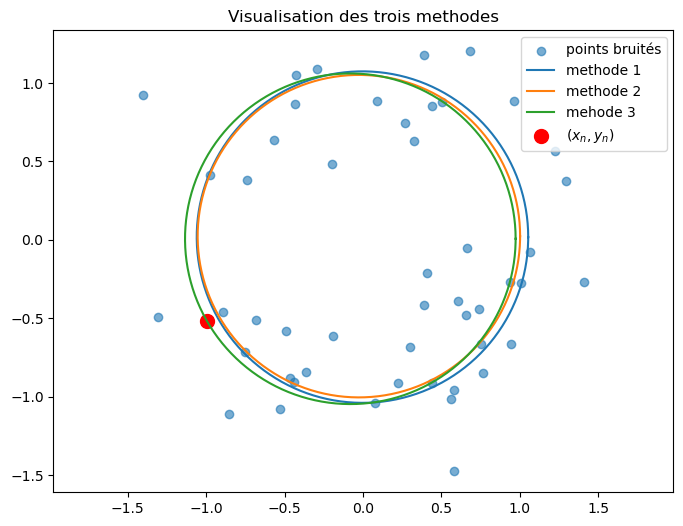

In [7]:
#superposition methode 1, 2 et 3
plt.figure(figsize=(8, 6))

plt.scatter(x_bruite, y_bruite, alpha=0.6, label="points bruités")

xc1, yc1, r1=methode1(x_bruite, y_bruite)
xc2, yc2, r2 =methode2(x_bruite,y_bruite)
xc3, yc3, r3 =methode3(x_bruite,y_bruite)

theta = np.linspace(0, 2*np.pi, 300)

x_cercle1 = xc1 + r1*np.cos(theta)
y_cercle1 = yc1 + r1*np.sin(theta)
plt.plot(x_cercle1, y_cercle1, label="methode 1 ")

x_cercle2 = xc2 + r2*np.cos(theta)
y_cercle2 = yc2 + r2*np.sin(theta)
plt.plot(x_cercle2, y_cercle2, label="methode 2 ")

x_cercle3 = xc3 + r3*np.cos(theta)
y_cercle3 = yc3 + r3*np.sin(theta)
plt.plot(x_cercle3, y_cercle3, label="mehode 3")

plt.scatter(x_bruite[-1], y_bruite[-1], color='red', s=100, label=r'$(x_n,y_n)$')

plt.axis("equal")
plt.title("Visualisation des trois methodes")
plt.legend()
plt.show()

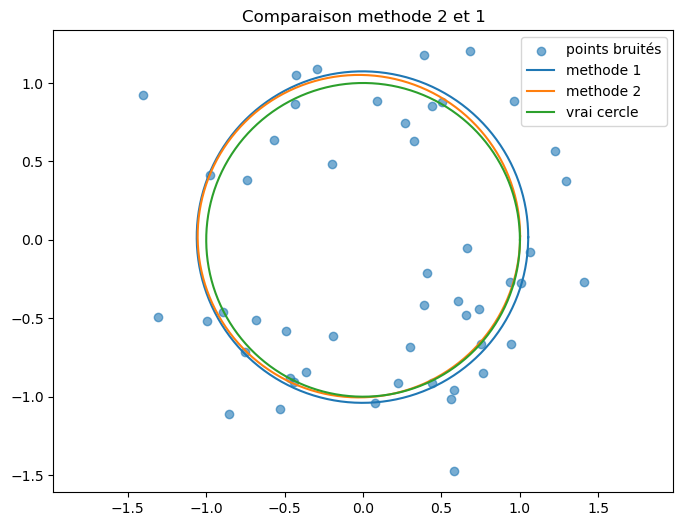

In [ ]:
theta = np.linspace(0, 2*np.pi, 300) 
r=1
x_vrai = r * np.cos(theta) 
y_vrai = r * np.sin(theta)

plt.figure(figsize=(8, 6))
plt.scatter(x_bruite, y_bruite, alpha=0.6, label="points bruités")
plt.plot(x_cercle1, y_cercle1, label="methode 1 ")
plt.plot(x_cercle2, y_cercle2, label="methode 2 ")
plt.plot(x_vrai, y_vrai, label="vrai cercle")

plt.axis("equal")
plt.title("Comparaison methode 2 et 1")
plt.legend()
plt.show()

Il est difficile de voir visuellement quelle est la courbe la meilleur approximation. Nous allons donc calculer l'erreur.

In [18]:
erreur1=0
erreur2=0
n=1000
for i in range(n):
    xc1, yc1, r1=methode1(x_bruite, y_bruite)
    xc2, yc2, r2 =methode2(x_bruite,y_bruite)
    erreur1+= xc1**2 + yc1**2 + (r1-1)**2
    erreur2+= xc2**2 + yc2**2 + (r2-1)**2

erreur1=erreur1/n
erreur2=erreur2/n

print(f"erreur methode 1: {erreur1}, \nerreur methode 2: {erreur2} ")

erreur methode 1: 0.40304516076572794, 
erreur methode 2: 0.32410916277697155 


On en conclu que la methode 2 est plus précise.

# Test sur le jeu de donnée 1

In [10]:
#import des données du jeu de données 1

data=pd.read_csv("data1.txt", header=None, sep=" ")

X=np.asarray(data[0], dtype=float)
Y=np.asarray(data[1], dtype=float)

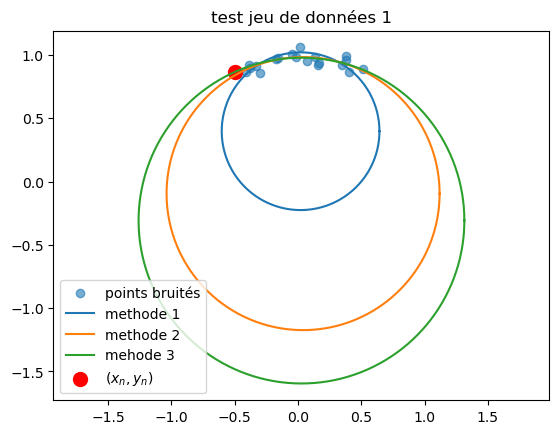

In [11]:
plt.scatter(X, Y, alpha=0.6, label="points bruités")

xc1, yc1, r1=methode1(X, Y)
xc2, yc2, r2 =methode2(X,Y)
xc3, yc3, r3 =methode3(X,Y)

theta = np.linspace(0, 2*np.pi, 300)

x_cercle1 = xc1 + r1*np.cos(theta)
y_cercle1 = yc1 + r1*np.sin(theta)
plt.plot(x_cercle1, y_cercle1, label="methode 1 ")

x_cercle2 = xc2 + r2*np.cos(theta)
y_cercle2 = yc2 + r2*np.sin(theta)
plt.plot(x_cercle2, y_cercle2, label="methode 2 ")

x_cercle3 = xc3 + r3*np.cos(theta)
y_cercle3 = yc3 + r3*np.sin(theta)
plt.plot(x_cercle3, y_cercle3, label="mehode 3")

plt.scatter(X[-1], Y[-1], color='red', s=100, label=r'$(x_n,y_n)$')

plt.axis("equal")
plt.title("test jeu de données 1")
plt.legend()
plt.show()

# Comparaison methode 1 et 2


On a déja montré que la methode 2 semble être la meilleur du point de vue de la précision. 

Calculons le coût computationnel des deux methodes

- Coût de la Méthode 1

La fonction construit une matrice $A \in \mathbb{R}^{n \times 3}$ et un vecteur $b \in \mathbb{R}^n$, ce qui coûte $O(n)$.  
La résolution du problème de moindres carrés avec 3 inconnues a aussi un coût linéaire en $n$, puisque le nombre de colonnes est constant.

-  Coût de la Méthode 2

L’initialisation coûte \(O(n)\). Ensuite, chaque évaluation de la fonction des résidus parcourt les $n$ points, donc coûte $O(n)$.  
Si l’algorithme effectue \(k\) itérations, le coût total est $O(k n)=O(n)$, où $k$ est le nombre d’itérations de `least_squares` borné par `max_nfev`.


On en conclu que les deux methodes on la même complexité asymptotique, mais à n fixé la methode 2 est plus couteuse. En effet la borne supérieur du temps de calcul est $C_2 k n$ pour la méthode 2 et $C_1 n$ pour la méthode 1, or on a surement $C_2 k>C_1$ car la méthode 2 repose sur une procédure itérative qui nécessite plusieurs évaluations des résidus, contrairement à la méthode 1 qui effectue une seule résolution.

Mesurons les temps de calculs de chaques methodes numériquement.

In [27]:

def mesurer_temps(f, data, repeat=10):
    x,y = data
    temps = []
    for _ in range(repeat):
        t0 = time.perf_counter()
        f(x, y)
        t1 = time.perf_counter()
        temps.append(t1 - t0)
    return np.mean(temps)

tailles = [100, 500, 1000, 2000, 5000, 10000]

In [31]:
temps1=[mesurer_temps(methode1, cree_cercle(n), repeat=10) for n in tailles]
temps2=[mesurer_temps(methode2, cree_cercle(n), repeat=10) for n in tailles]

coef1 = np.polyfit(tailles, temps1, 1)
coef2 = np.polyfit(tailles, temps2, 1)

C1 = coef1[0]
C2 = coef2[0]

print("C1 estimé =", C1)
print("C2 estimé =", C2)

C1 estimé = 1.8216152893528141e-07
C2 estimé = 3.949710309695316e-07


Ces résultats confirment que la méthode 2 est plus couteuse

# Méthode proposée pour l'ellipse

D'après la comparaison ci-dessus et les résultats de l'article de Gander, W., Golub, G.H. & Strebel, R. Least-squares fitting of
circles and ellipses, nous proposons un ajustement géométrique par Gauss–Newton avec une initialisation algébrique. En effet cette methode permettra de combiner la rapidité et le faible cout computationnelle de la méthode linéaire avec la précision de la methode non linéaire.

## 1. Initialisation algébrique

L'équation générale d'une ellipse est de la forme:

$$
ax^2 + bxy + by^2 + dx + ey + f = 0.
$$

L'article utilise l'écriture matricielle suivante:
$$
z^\top A z + B^\top z + f = 0,
$$

où

$$
z =
\begin{pmatrix}
x\\y
\end{pmatrix},
\qquad
A =
\begin{pmatrix}
a & b/2\\
b/2 & c
\end{pmatrix},
\qquad
B =
\begin{pmatrix}
d\\e
\end{pmatrix},
\qquad
$$

Notons $X$ la matrice contenant les données telles que les lignes correspondent au $n$ observtions. l'équation s'écrit alors

$$
X u=0,
$$

où

$$
u=(A_{11},\,2A_{12},\,A_{22},\,B_1,\,B_2,\,f)^\top= (a,b,c,d,e,f)
$$

Nous allons determiner les paramêtres $A,B,f$ de l'ellipse qui ajuste le mieux nos données par la methode linéaire décrite dans l'aticle partie 3.1 .
Mais comme ce système homogène admet toujours la solution triviale \(u=0\), il faut imposer une contrainte. D'après l'article, La contrainte standard $\|u\|=1$ n'est pas satisfaisante, car elle n'est pas invariante par rotatation et translation du repère. Pour cette raison, on utilise la contrainte de Bookstein.

$$\lambda_1^2+\lambda_2^2 = A_{11}^2 + 2A_{12}^2 + A_{22}^2 = 1$$

où $\lambda_1,\lambda_2$ sont les valeurs propres de la matrice $A$



In [12]:

def init_ellipse_bookstein(x, y):
    """
    Initialisation algébrique d'une ellipse avec contrainte de Bookstein.

    Paramètres
    ----------
    x, y : array (1,n)
        Coordonnées des points.

    Retour
    ------
    
    A : ndarray shape (2,2)
        Matrice quadratique symétrique.
    B : ndarray shape (2,)
        Vecteur linéaire.
    f : float
        Terme constant.

        
    """
    S = np.column_stack((x, y, np.ones_like(x), x**2, np.sqrt(2) * x * y, y**2))

    # décomposition QR de S
    _, R = np.linalg.qr(S, mode="reduced")
    R11 = R[:3, :3]
    R12 = R[:3, 3:]
    R22 = R[3:, 3:]

    # Bookstein : ||w|| = 1 equivalent à A_{11}^2 + 2A_{12}^2 + A_{22}^2 = 1
    _, _, V3 = np.linalg.svd(R22) #3eme valeur singulière de R22
    w = V3[-1]                     # shape (3,) [a11, sqrt(2)a12, a22]

    v = -np.linalg.solve(R11, R12 @ w)

    # calcul des coefficients
    a11 = w[0]
    a12 = w[1] / np.sqrt(2)
    a22 = w[2]
    b1, b2, f = v

    A = np.array([[a11, a12],
                  [a12, a22]])
    B = np.array([b1, b2])      

    return A, B, f

## 2. Calcul des demies axes, centre et inclinaison de l'ellipse initiale

Supposons à présent que $A, B, f$ sont solutions de la méthode linéaire. 

$A\in\mathbb{R}^{2\times 2}$ est une matrice symétrique, dans le cas d’une ellipse, elle est aussi définie positive d'après l'article. Elle est donc diagonalisable dans une base orthornormée est on écrit $A=Q^\top \widetilde{A} Q$ où $Q$ est ortogonale et $\widetilde{A}= diag(\lambda_1, \lambda_2)$. 

On effectue ensuite le changement de repère:

$$
z = Q\tilde{z} + t
$$

de sorte que l'équation s'écrive

$$
\tilde{z}^\top \widetilde{A}\tilde{z}+\widetilde{B}^\top \tilde{z}+\widetilde{f}=0
$$

où 
$\qquad
\widetilde{B}:= 2t^t A +B^t, 
\qquad
\widetilde{f}:=t^t + A t + B^t + f$

puis on choisi $t_0$ tel que $\widetilde{B}=0$ et on note $\tilde{z}=(\tilde{x},\tilde{y})$, l'équation devient alors:




$$
\frac{\tilde{x}^2}{-\widetilde{f}/\lambda_1}
+
\frac{\tilde{y}^2}{-\widetilde{f}/\lambda_2}
=1.
$$

On lit alors immédiatement les demi-axes :

$$
v_1^{(0)}=\sqrt{\frac{-\widetilde{f}}{\lambda_1}},
\qquad
v_2^{(0)}=\sqrt{\frac{-\widetilde{f}}{\lambda_2}}.
$$

Le centre de l’ellipse dans le repère initial est donné par le vecteur de translation $t_0$.

l’orientation de l’ellipse est donnée par la matrice de rotation $Q$. 


In [ ]:
def init_parameters(A, B, f):
    """
    Initialisation robuste des paramètres géométriques d'une ellipse
    à partir de A, B, f, même si la conique n'est pas une ellipse réelle.

    Paramètres
    ----------
    A : array (2,2)
    B : array (2,) ou (2,1)
    f : float

    Retourne
    --------
    t1, t2 : centre
    v1, v2 : demi-axes
    alpha  : angle
    """
    # 1) Symétrisation
    A = 0.5 * (A + A.T)

    #Calcul de t0 robuste à la non inversibilité de A
    try:
        center = -0.5 * np.linalg.solve(A, B)
    except np.linalg.LinAlgError:
        center = -0.5 * (np.linalg.pinv(A) @ B)
    
    #calcul des demies axes robuste aux valeurs nulles pour eviter les NaN
    f_tilde = float(center.T @ A @ center + B.T @ center + f) 
    f_abs = max(abs(f_tilde), 0.0001)#forcer la stricte positivité
    eigvals, eigvecs = np.linalg.eigh(A) #valeurs propres, vecteurs propres
    eigvals = np.maximum(np.abs(eigvals), 0.0001) #forcer la stricte positivité
    
    axes = np.sqrt(f_abs / eigvals)
    alpha = np.arctan2(eigvecs[1, 0], eigvecs[0, 0])
    
    return center[0], center[1], axes[0], axes[1], alpha

## 3. Itération de Gauss-Newton

L’ellipse peut être décrite sous forme paramétrique :

$$
\forall \varphi \in [0,2\pi[,
\qquad
t+P(\alpha)
\begin{pmatrix}
v_1\cos\varphi\\
v_2\sin\varphi
\end{pmatrix}
$$

où

$$t=(t_1,t_2)\in\mathbb{R}^2,\qquad v_1,v_2>0, \qquad P(\alpha) =\begin{pmatrix}
\cos\alpha & -\sin\alpha\\
\sin\alpha & \cos\alpha
\end{pmatrix}$$

Notons $z_i=(x_i,y_i)\in\mathbb{R}^2$, pour $i=1,\dots,m$, les points observés. Pour chaque point $z_i$, on introduit un paramètre $\varphi_i$ localisant le point correspondant sur l’ellipse.
Notons  $g_i(u):=z_i-t-P(\alpha)\begin{pmatrix}v_1\cos\varphi_i\\v_2\sin\varphi_i\end{pmatrix}$

on cherche donc $u=(\varphi_1,\dots,\varphi_m,v_1,v_2,t_1,t_2,\alpha)$ qui minimise $\sum_{i=1}^m \|g_i(u)\|^2$

Comme pour la méthode 2 on construit une suite $(u_n)$ convergent vers $u^*$ tel que $u_0=(\varphi_1^{(0)},\dots,\varphi_m^{(0)},v_1^{(0)},v_2^{(0)},t_1^{(0)},t_2^{(0)},\alpha_0)$ en notant $t_0=(t_1^{(0)},t_2^{(0)})$ et $\alpha_0$ l'angle de rotation de $Q$ tel que :

$$
Q=
\begin{pmatrix}
\cos\alpha_0 & -\sin\alpha_0\\
\sin\alpha_0 & \cos\alpha_0
\end{pmatrix}
$$

Rappelons que $t_0,v_1^{(0)},v_2^{(0)} $ et $\alpha_0$ sont issues de la résolution de la methode linéaire, il reste donc à choisir $\varphi_1^{(0)},\dots,\varphi_m^{(0)}$.


In [ ]:
#fonction principale

def methode_ellipse(x, y, method='lm', max_nfev=1000):
    '''
    Ajustement géométrique d'une ellipse par moindres carrés géométrique
    '''

    # 1) initialisation algébrique
    A, B, f = init_ellipse_bookstein(x, y)

    # 2) initialisation géométrique
    t1, t2, v1, v2, alpha = init_parameters(A, B, f)
    
    # 3) initialisation des phi_i
    Q = np.array([[np.cos(alpha), -np.sin(alpha)],
                  [np.sin(alpha),  np.cos(alpha)]])

    pts = np.column_stack((x, y))
    local = (pts - (t1,t2)) @ Q   # coordonnées dans le repère de l'ellipse

    Phi0 = np.arctan2(local[:, 1] / v2, local[:, 0] / v1)

    # vecteur initial des paramètres
    theta0 = np.concatenate([[t1, t2, v1, v2, alpha], Phi0])

    # résidus
    def residus(theta):
        t1, t2, v1, v2, alpha = theta[:5]
        phi=theta[5:]

        cos_a = np.cos(alpha)
        sin_a = np.sin(alpha)

        x_model = t1 + cos_a * (v1 * np.cos(phi)) - sin_a * (v2 * np.sin(phi))
        y_model = t2 + sin_a * (v1 * np.cos(phi)) + cos_a * (v2 * np.sin(phi))

        return np.concatenate([x - x_model, y - y_model])

    result = least_squares(residus, x0=theta0, method=method, max_nfev=max_nfev)

    return result.x[:5]

---

### Test sur un jeu de donnée crée

In [118]:
random.seed()

#création d'un jeu de données de test

n=100 #nombre de points

# selection de points issus de la vraie ellipse
t1, t2 = 0, 0 #centre
v1, v2,= 1, 2 #demie-axe
alpha=2 #angle de rotation
phi = np.random.uniform(0, 2*np.pi, n) 

x = t1+ v1*np.cos(phi)*np.cos(alpha) - v2*np.sin(phi)*np.sin(alpha)
y = t2+ v1*np.cos(phi)*np.sin(alpha) + v2*np.sin(phi)*np.cos(alpha)

#bruitage des points
sigma=0.1
bruit = np.random.normal(loc=0, scale=np.sqrt(sigma), size=(n, 2))
x_bruite = x + bruit[:,0]
y_bruite = y + bruit[:,1]

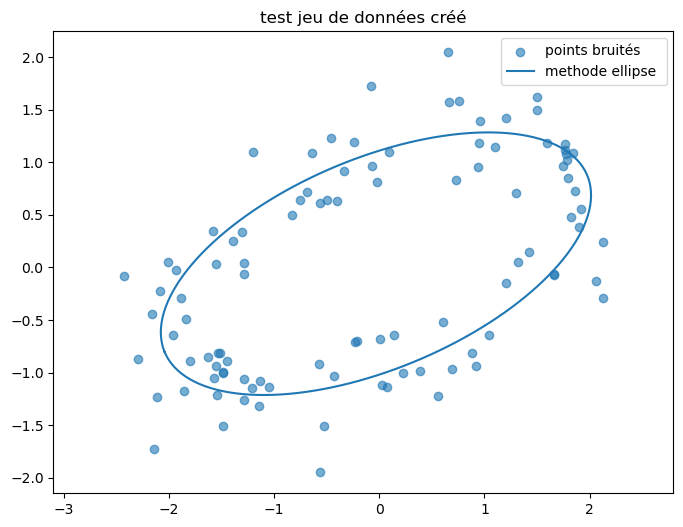

In [119]:
plt.figure(figsize=(8, 6))

plt.scatter(x_bruite, y_bruite, alpha=0.6, label="points bruités")

t1, t2, v1, v2, alpha = methode_ellipse(x_bruite,y_bruite)
phi = np.linspace(0, 2*np.pi,300) 

x_ellipse = t1+ v1*np.cos(phi)*np.cos(alpha) - v2*np.sin(phi)*np.sin(alpha)
y_ellipse = t2+ v1*np.cos(phi)*np.sin(alpha) + v2*np.sin(phi)*np.cos(alpha)

plt.plot(x_ellipse, y_ellipse, label="methode ellipse ")

plt.axis("equal")
plt.title("test jeu de données créé")
plt.legend()
plt.show()

---

### Test jeu de donnée 2

In [120]:
data2=pd.read_csv("data2.txt", header=None, sep=" ")

X2=np.asarray(data[0], dtype=float)
Y2=np.asarray(data[1], dtype=float)

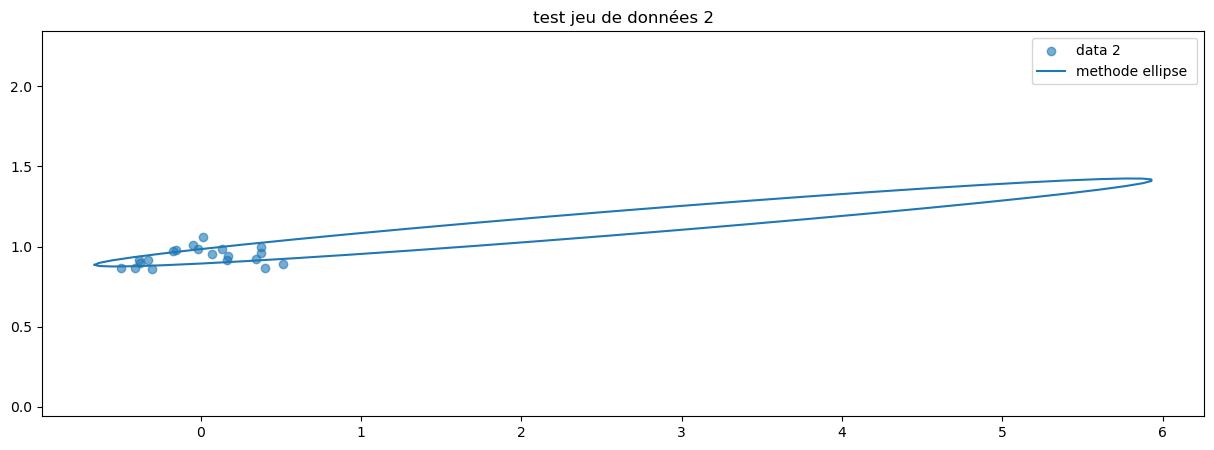

In [126]:
plt.figure(figsize=(15, 5))

plt.scatter(X2, Y2, alpha=0.6, label="data 2")

t1, t2, v1, v2, alpha = methode_ellipse(X2,Y2)
phi = np.linspace(0, 2*np.pi) 

x_ellipse = t1+ v1*np.cos(phi)*np.cos(alpha) - v2*np.sin(phi)*np.sin(alpha)
y_ellipse = t2+ v1*np.cos(phi)*np.sin(alpha) + v2*np.sin(phi)*np.cos(alpha)

plt.plot(x_ellipse, y_ellipse, label="methode ellipse ")

plt.axis("equal")
plt.title("test jeu de données 2")
plt.legend()
plt.show()